In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [8]:
govt = pd.read_csv('../DATA/FederalSpending_MandatoryOutlays_1962-2025.csv')
govt = govt.rename(columns={'Major health care programs (GPD)':'Major health care programs (GDP)'})
govt.head(3)

,Year,Social Security,Social Security (GDP),Medicare,Medicare (GDP),Medicaid,Medicaid (GDP),Income security,Income security (GDP),Major health care programs,Major health care programs (GDP)
0,1962,14,2.4,0.0,0.0,0.1,0.0,6.1,1.0,0.1,0.0
1,1963,15.5,2.5,0.0,0.0,0.2,0.0,6.5,1.0,0.2,0.0
2,1964,16.2,2.5,0.0,0.0,0.2,0.0,6.4,1.0,0.2,0.0


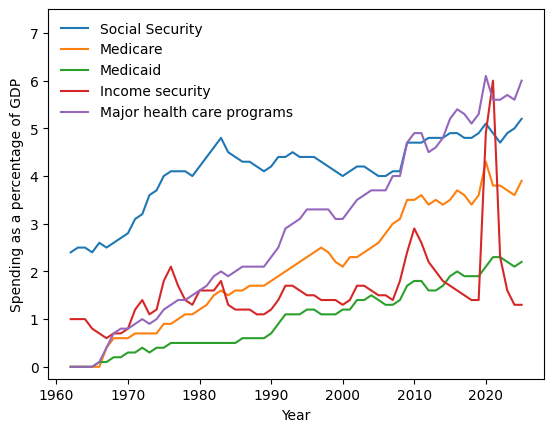

In [9]:
plt.plot(govt['Year'], govt['Social Security (GDP)'],label = 'Social Security')
plt.plot(govt['Year'], govt['Medicare (GDP)'],label = 'Medicare')
plt.plot(govt['Year'], govt['Medicaid (GDP)'],label = 'Medicaid')
plt.plot(govt['Year'], govt['Income security (GDP)'],label = 'Income security')
plt.plot(govt['Year'], govt['Major health care programs (GDP)'],label = 'Major health care programs')
plt.legend(framealpha=0)
plt.ylabel('Spending as a percentage of GDP')
plt.xlabel('Year')
plt.ylim(-0.25,7.5)
plt.savefig('../OUTPUTS/spending.png',dpi=300)


In [14]:
death = pd.read_csv('../DATA/DeathRatesAndLifeExpectancy.csv')
death.head(3)

,Year,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate
0,1900,All Races,Both Sexes,47.3,"2,518.0"
1,1901,All Races,Both Sexes,49.1,"2,473.1"
2,1902,All Races,Both Sexes,51.5,"2,301.3"


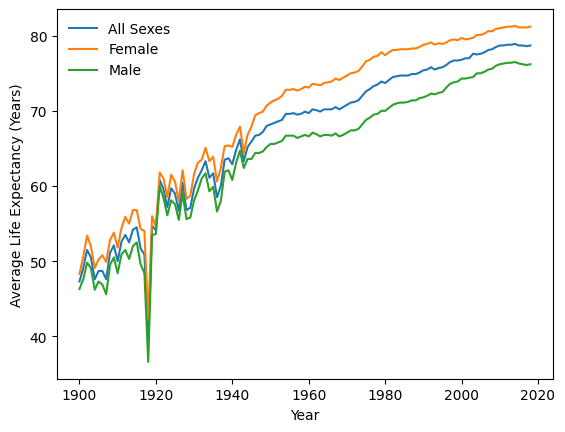

In [15]:
all_all = death[(death['Race'] == 'All Races') & (death['Sex'] == 'Both Sexes')]
all_women = death[(death['Race'] == 'All Races') & (death['Sex'] == 'Female')]
all_men = death[(death['Race'] == 'All Races') & (death['Sex'] == 'Male')]

plt.plot(all_all['Year'], all_all['Average Life Expectancy (Years)'], label = 'All Sexes')
plt.plot(all_women['Year'], all_women['Average Life Expectancy (Years)'], label = 'Female')
plt.plot(all_men['Year'], all_men['Average Life Expectancy (Years)'], label = 'Male')
plt.legend(framealpha=0)
plt.ylabel('Average Life Expectancy (Years)')
plt.xlabel('Year')
plt.savefig('../OUTPUTS/life_exp.png',dpi=300)

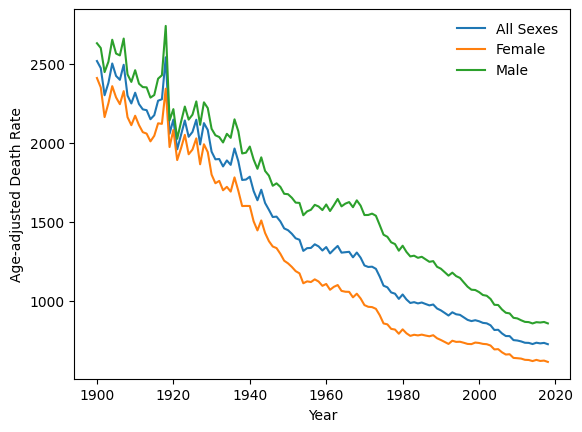

In [17]:
all_all = death[(death['Race'] == 'All Races') & (death['Sex'] == 'Both Sexes')]
all_women = death[(death['Race'] == 'All Races') & (death['Sex'] == 'Female')]
all_men = death[(death['Race'] == 'All Races') & (death['Sex'] == 'Male')]

plt.plot(all_all['Year'], all_all['Age-adjusted Death Rate'].str.replace(',','').astype(float), label = 'All Sexes')
plt.plot(all_women['Year'], all_women['Age-adjusted Death Rate'].str.replace(',','').astype(float), label = 'Female')
plt.plot(all_men['Year'], all_men['Age-adjusted Death Rate'].str.replace(',','').astype(float), label = 'Male')
plt.legend(framealpha=0)
plt.ylabel('Age-adjusted Death Rate')
plt.xlabel('Year')
plt.savefig('../OUTPUTS/death_rate.png',dpi=300)

In [25]:
hstpov4 = pd.read_csv('../DATA/Datasets  - hstpov4concise.csv')
hstpov7 = pd.read_csv('../DATA/Datasets  - hstpov7concise.csv')

In [35]:
# Combined dataset
combined = pd.merge(govt, hstpov7, on='Year', how='inner')
combined = pd.merge(combined, death, on='Year', how='inner')
combined = pd.merge(combined, hstpov4, on='Year', how='inner')
combined.head(20)

,Year,Social Security,Social Security (GDP),Medicare,Medicare (GDP),Medicaid,Medicaid (GDP),Income security,Income security (GDP),Major health care programs,...,Female Total Below Poverty Percent,Female Under 18 Below Poverty Percent,Female 18 to 64 Below Poverty Percent,Female 64 and Over Below Poverty Percent,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate,All Families Below Poverty (With and Without Children) Percent,All Families Below Poverty (Without Children) Percent
0,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,All Races,Both Sexes,70.2,"1,309.0",11.8,13.4
1,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,All Races,Female,73.9,"1,055.3",11.8,13.4
2,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,All Races,Male,66.7,"1,624.2",11.8,13.4
3,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,Black,Both Sexes,64.2,"1,529.7",11.8,13.4
4,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,Black,Female,67.6,"1,274.6",11.8,13.4
5,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,Black,Male,60.9,"1,832.4",11.8,13.4
6,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,White,Both Sexes,71.1,"1,278.7",11.8,13.4
7,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,White,Female,74.8,"1,024.7",11.8,13.4
8,1966,20.3,2.6,0.0,0.0,0.8,0.1,5.2,0.7,0.8,...,16.3,17.8,12.1,32.0,White,Male,67.5,"1,595.7",11.8,13.4
9,1967,21.3,2.5,3.2,0.4,1.2,0.1,5.2,0.6,3.7,...,15.8,15.7,11.3,32.3,All Races,Both Sexes,70.5,"1,274.0",11.4,12.4


In [36]:
# Output data set as csv
combined.to_csv('../DATA/Combined_Dataset.csv', index=False)

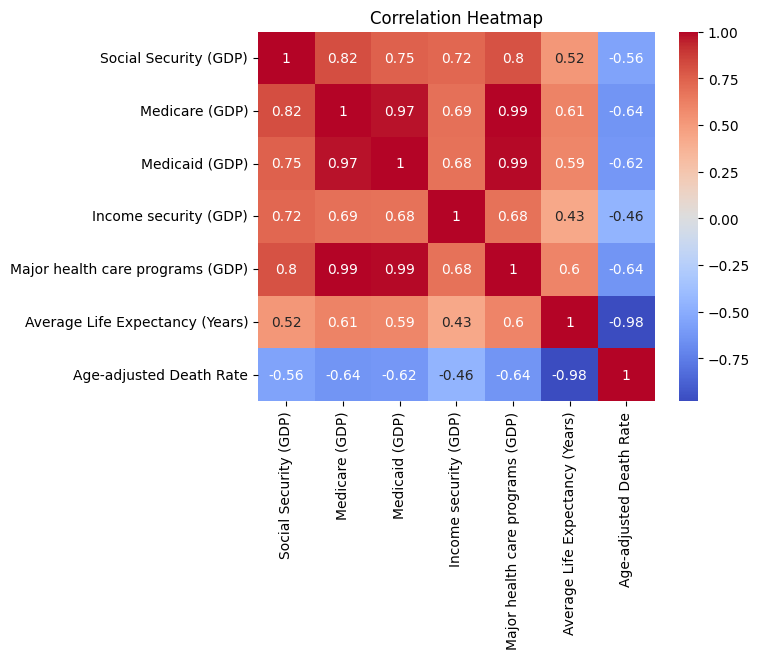

In [ ]:
# Correlation between Social Security spending and life expectancy
combined_drop = combined.drop(columns=['Year','Medicaid'])
combined_drop['Age-adjusted Death Rate'] = combined_drop['Age-adjusted Death Rate'].str.replace(',','').astype(float)

corr  = combined_drop.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('../OUTPUTS/correlation_heatmap.png',dpi=500)